In [ ]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_preprocessing import load_data, preprocess_data
from src.train_model import train_baseline_model, train_optimized_model 
from src.evaluate import evaluate_model 
from src.evaluate_model import evaluate
from src.advanced_models import train_xgboost
from src.feature_importance import plot_feature_importance
from src.visualisations import plot_roc_curve

In [2]:
from src.advanced_models import train_xgboost
from src.feature_importance import plot_feature_importance
from src.visualisations import plot_roc_curve

In [3]:
df = load_data("../data/telco_churn.csv")

df.head()

,scustomerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   scustomerID       7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


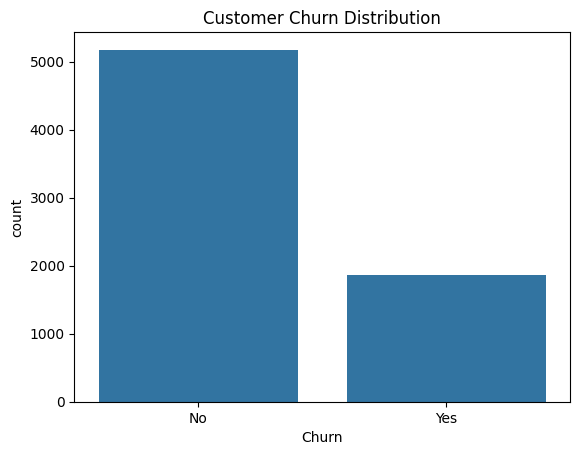

In [5]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

def preprocess_data(df):
    # 1️⃣ Clean column names
    df.columns = df.columns.str.strip()

    # 2️⃣ Drop customerID safely
    df = df.drop("customerID", axis=1, errors="ignore")

    # 3️⃣ Convert TotalCharges to numeric
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # 4️⃣ Drop rows with missing TotalCharges or Churn
    df = df.dropna(subset=["TotalCharges", "Churn"])

    # 5️⃣ Separate features and target
    X = df.drop("Churn", axis=1)
    y = df["Churn"].map({"Yes": 1, "No": 0})  # Encode target as 0/1

    # 6️⃣ One-Hot Encode all categorical features
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # 7️⃣ Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    return X_train, X_test, y_train, y_test

# Optional: check columns before preprocessing
print(df.columns.tolist())

# Run preprocessing
X_train, X_test, y_train, y_test = preprocess_data(df)

# Optional: check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

['scustomerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


C:\Users\dell\AppData\Local\Temp\ipykernel_14380\1052499396.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


X_train shape: (5625, 7061)
X_test shape: (1407, 7061)
y_train shape: (5625,)
y_test shape: (1407,)


In [7]:
baseline_model = train_baseline_model(X_train, y_train)
evaluate(baseline_model, X_test, y_test)

c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7270788912579957
ROC AUC: 0.7476096308452097
Confusion Matrix:
[[727 306]
 [ 78 296]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [8]:
print("X_train shape:", X_train.shape)
print("Number of features:", len(X_train.columns))

X_train shape: (5625, 7061)
Number of features: 7061


In [9]:
optimized_model = train_optimized_model(X_train, y_train)
evaluate(optimized_model, X_test, y_test)

Accuracy: 0.7327647476901208
ROC AUC: 0.7446588773677209
Confusion Matrix:
[[743 290]
 [ 86 288]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.77      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



In [10]:
xgb_model = train_xgboost(X_train, y_train)

evaluate(xgb_model, X_test, y_test)

c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:52:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7931769722814499
ROC AUC: 0.7064841513477697
Confusion Matrix:
[[921 112]
 [179 195]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [11]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": baseline_model,
    "Random Forest": optimized_model,
    "XGBoost": xgb_model
}

results = {}

for name, model in models.items():

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results[name] = acc

print(results)

{'Logistic Regression': 0.7270788912579957, 'Random Forest': 0.7327647476901208, 'XGBoost': 0.7931769722814499}


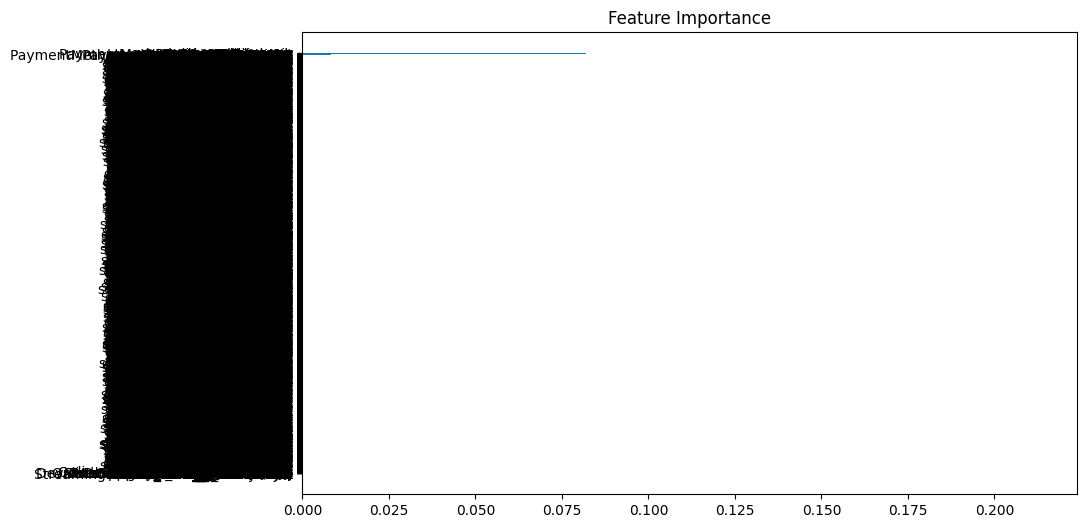

In [12]:
# Use the columns of X_train, which were used to train the model
feature_names = X_train.columns

# Plot feature importance
plot_feature_importance(xgb_model, feature_names)

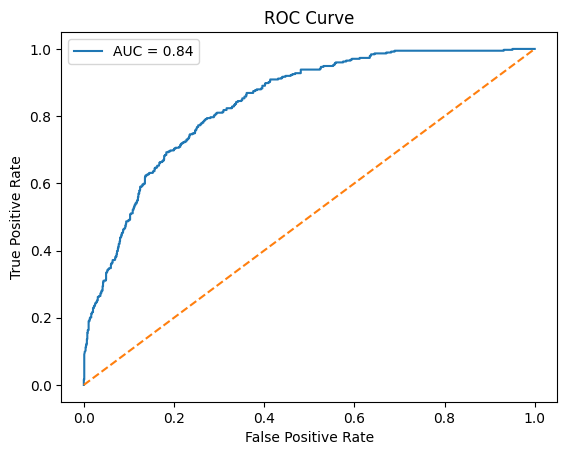

In [13]:
plot_roc_curve(xgb_model, X_test, y_test)

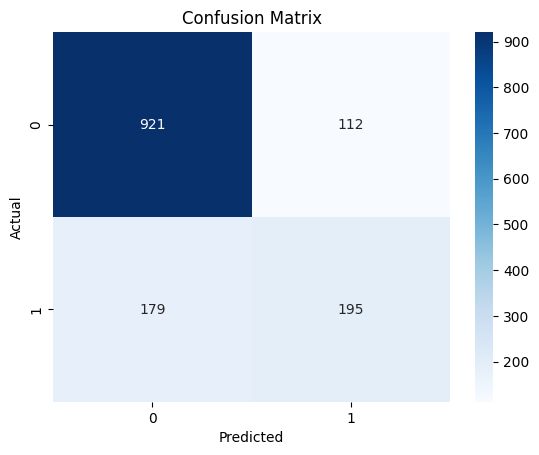

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

def preprocess_data(df):
    # 1. Clean column names
    df.columns = df.columns.str.strip()

    # 2. Drop customerID safely
    df = df.drop("customerID", axis=1, errors="ignore")

    # 3. Convert TotalCharges
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # 4. Clean target FIRST
    df["Churn"] = df["Churn"].astype(str).str.strip()

    # 5. Drop missing values
    df = df.dropna(subset=["TotalCharges", "Churn"])

    # 6. Define X and y (IMPORTANT: BEFORE using X)
    X = df.drop("Churn", axis=1)
    y = df["Churn"].replace({"Yes": 1, "No": 0}).astype(int)

    # 7. Handle categorical features
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

    # Optional: remove high-cardinality columns
    high_card_cols = [col for col in cat_cols if X[col].nunique() > 20]
    X = X.drop(columns=high_card_cols)

    # One-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    # 8. Final safety check
    assert X.isnull().sum().sum() == 0, "NaNs found in features"
    assert set(y.unique()).issubset({0, 1}), "Target not encoded properly"

    # 9. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X_train, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Score:", scores.mean())

c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:56:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:56:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:56:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\dell\Downloads\AI_Customer_Churn_Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:56:47] WARNING: C:\actio

Cross Validation Scores: [0.79377778 0.83377778 0.79644444 0.79377778 0.78844444]
Mean Score: 0.8012444444444444


In [17]:
from src.save_model import save_model

save_model(xgb_model, "churn_model.pkl")

In [18]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
y_pred_lr = baseline_model.predict(X_test)
y_proba_lr = baseline_model.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Logistic Regression ROC-AUC: 0.8230544439900401
XGBoost ROC-AUC: 0.8387697946379113


In [19]:
print("=== Logistic Regression ===")
evaluate_model(baseline_model, X_test, y_test)

print("=== Optimized Logistic ===")
evaluate_model(optimized_model, X_test, y_test)

print("=== XGBoost ===")
evaluate_model(xgb_model, X_test, y_test)

=== Logistic Regression ===
Confusion Matrix:
[[727 306]
 [ 78 296]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


ROC-AUC Score:
0.8230544439900401
=== Optimized Logistic ===
Confusion Matrix:
[[743 290]
 [ 86 288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.77      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407


ROC-AUC Score:
0.8344821427647007
=== XGBoost ===
Confusion Matrix:
[[921 112]
 [179 195]]

Classification Report:
          

In [20]:
from src.save_model import save_model

save_model(xgb_model, "churn_model.pkl")

In [21]:
print("Pipeline executed successfully.")

Pipeline executed successfully.
